# Week 10: Distributions and Evaluating Statistical Models

**Tomo Parins-Fukuchi**

## Recap of Data Visualization

- We have seen histograms and boxplots
- What do they tell us?

### Shape of a Histogram: Modality

<img src="modes.png" width="800">

### Shape of a Histogram: Skewness

<img src="symmetry.png" width="800">

## Percentiles

The $k^{th}$ percentile is a point in the data in which $k$% of the data is below that percentile.

> For example, if 170 cm is the $90^{th}$ percentile for female heights, that means that 90% of females are below 170 cm tall.

## Percentiles

+ the **median** is the $50^{th}$ percentile.
+ the **first quartile (Q1)** is the $25^{th}$ percentile.
+ the **third quartile (Q3)** is the $75^{th}$ percentile.

### Shape of a Boxplot

<img src="boxplot.png" width="400">

### Shape of a Boxplot: Skewness

<img src="boxplot_skew.png" width="800">

## Centre of the data

- If you have the following data:

$$ {3, 3, 4, 4, 4, 5, 5, 5, 5, 6, 6, 6, 7, 7}$$

- What is the *mean*? what is the *median*?

In [1]:
import numpy as np
import matplotlib.pyplot as plt

vals = [3, 3, 4, 4, 4, 5, 5, 5, 5, 6, 6, 6, 7, 7]

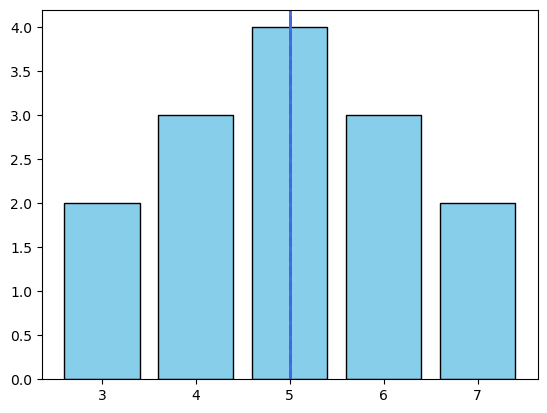

In [2]:
bins = np.arange(min(vals), max(vals) + 2) - 0.5
mean_val = np.mean(vals)
median_val = np.median(vals)

plt.hist(vals, bins=bins, rwidth=0.8, color='skyblue', edgecolor='black')
plt.axvline(mean_val, color='crimson', ls='--', lw=2, label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='royalblue', ls='-', lw=2, label=f'Median: {median_val}')
plt.xticks(range(min(vals), max(vals) + 1))
plt.show()

### Outliers

What if your data was right skewed? What is the *mean* and what is the *median* for the data below? 

In [3]:
vals = [3, 3, 4, 4, 4, 5, 5, 5, 5, 6, 6, 6, 7, 7, 20, 23]

### Outliers


The <b style="color: crimson;">mean</b> gets pulled toward the outliers while the <b style="color: royalblue;">median</b> is less sensitive to outliers

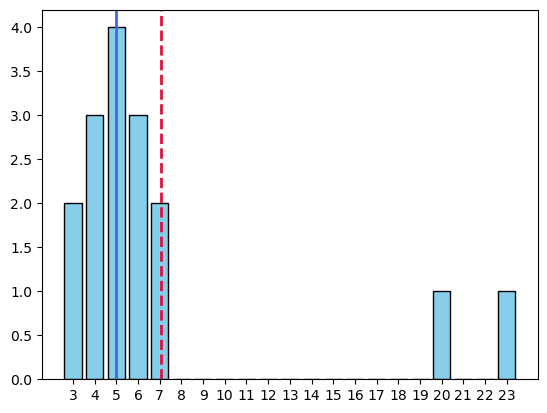

In [4]:
bins = np.arange(min(vals), max(vals) + 2) - 0.5
mean_val = np.mean(vals)
median_val = np.median(vals)

plt.hist(vals, bins=bins, rwidth=0.8, color='skyblue', edgecolor='black')
plt.axvline(mean_val, color='crimson', ls='--', lw=2, label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='royalblue', ls='-', lw=2, label=f'Median: {median_val}')
plt.xticks(range(min(vals), max(vals) + 1))
plt.show()

### Skewed data

What if your data was right skewed? What is the *mean* and what is the *median* for the data below? 

In [6]:
import numpy as np
import matplotlib.pyplot as plt

vals = [3, 3, 3, 3, 3, 4, 4, 4, 5, 5, 6, 6, 7, 9, 10, 20]

### Skewed data


The <b style="color: crimson;">mean</b> gets pulled toward the outliers while the <b style="color: royalblue;">median</b> is less sensitive to outliers. This makes median a better representation for skewed data, or data with a lot of outliers, in general.

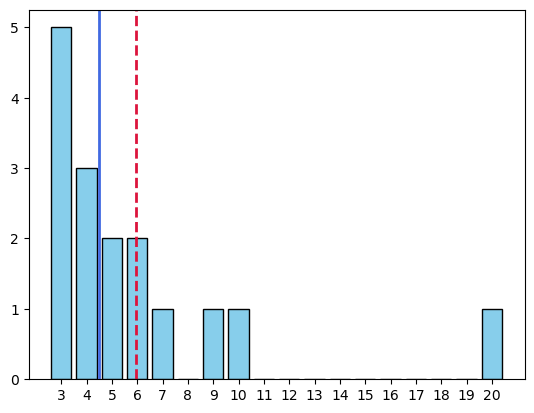

In [7]:
bins = np.arange(min(vals), max(vals) + 2) - 0.5
mean_val = np.mean(vals)
median_val = np.median(vals)

plt.hist(vals, bins=bins, rwidth=0.8, color='skyblue', edgecolor='black')
plt.axvline(mean_val, color='crimson', ls='--', lw=2, label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='royalblue', ls='-', lw=2, label=f'Median: {median_val}')
plt.xticks(range(min(vals), max(vals) + 1))
plt.show()

### Skewed data

Generally, we have:

+ symmetric data has: mean $\approx$ median
+ left-skewed data has: mean < median
+ right-skewed data has: mean > median

## The Bootstrap

- What if instead we wanted to just look at a statistic and provide a reasonable range of values it could take? 

- We can apply a technique called **"bootstrapping"**

- E.g., we might say "we are confident that the mean heights of all females is between 164 cm and 167 cm."

## The Bootstrap


<div style="display:flex; justify-content: space-between; column-gap: 25px;">
<div>
<p>A data scientist is using the data in a random sample to estimate an unknown statistical parameter.</p>
<p>They use the sample to calculate the value of a statistic to estimate.</p>
</div>
<div>
<img src="stats00.png" width="50%">
</div>

</div>

## The Bootstrap

<div>
<p>But our estimate of this statistic could vary randomly because we only computed it from a limited sample</p>
</div>

<div style="display:flex; justify-content: space-between; column-gap: 25px;">
<div>
<img src="stats01.png" width="50%">
</div>

</div>

## The Bootstrap

<div>
<p>By how much could those estimates vary? </p>
<p>To answer this, it appears as though they need to draw another sample from the population, and compute a new estimate based on the new sample, and repeat, and repeat...</p> 
<p>But they don't have the resources to go back to the population and draw another sample.</p>
</div>

<div style="display:flex; justify-content: space-between; column-gap: 25px;">
<div>
<img src="stats02.png" width="50%">
</div>

</div>


## The Bootstrap

- Generate new random samples by **resampling** our data
  - New samples are drawn at random from the original sample
  - This simulates the act of "re-collecting" our dataset many times

## The Bootstrap

- Suppose you sample 5 students and see that their heights are: 
    $${160, 162, 165, 168, 170}$$
- The median of this sample is **165**

In [8]:
def plt_sample(samp):
    """Display resampled values.
    
    Don't worry about the code. Treat it as a black box.
    """
    fig = plt.scatter(None, None)
    max_n = 0
    for (x, n) in samp.value_counts().items():
        max_n = np.max([n, max_n])
        for y in np.arange(n):
            plt.scatter(x=x, y=y, s=50,
                        color="lightgrey",
                        edgecolor="grey")
    plt.ylim([-1, max_n])
    plt.xlim([159, 171])
    plt.xticks([160, 162, 165, 168, 170])
    plt.axvline(x=np.median(samp), color="forestgreen")
    ax = fig.axes
    ax.get_yaxis().set_visible(False)
    ax.set_aspect(1)


165.0

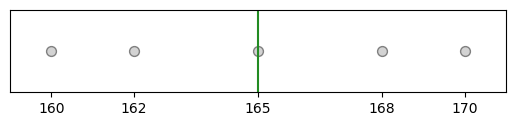

In [9]:
import pandas as pd
heights = pd.Series([160, 162, 165, 168, 170])
plt_sample(heights);
heights.median()

## The Bootstrap

- Suppose we want to estimate the _true_ median height in the larger student body
- Our dataset is pretty small and so may contain error
- **How much would our estimate of the median change if we'd randomly chosen 5 other students from the broader student body?** 


## The law of averages

- The distribution of the original sample is likely to resemble the population

- If we randomly pick items from our sample, they are also likely to resemble the original sample 

- The distribution of this "resampling" is also likely to resemble the population

## The Bootstrap

- One example of a "resample" of the original sample/data is:


  $$ {165, 168, 168, 168, 170} $$

- The median of this resample is 168

median: 168.0


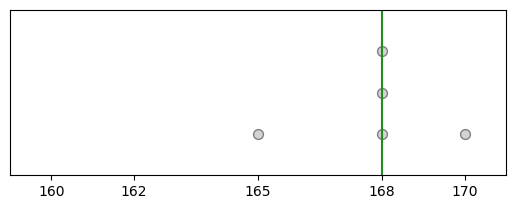

In [10]:
np.random.seed(125)
heights_1 = heights.sample(frac=1, replace=True)
plt_sample(heights_1);
print("median:" ,heights_1.median())

## The Bootstrap

- Another resample of the original sample/data is:
  $${160, 162, 165, 168, 170} $$
- The median of this resample is 165

median: 165.0


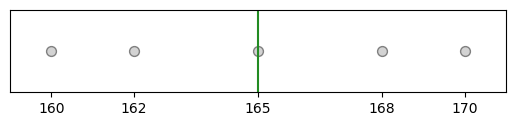

In [11]:
np.random.seed(126)

heights_2 = heights.sample(frac=1, replace=True)
plt_sample(heights_2);
print("median:" ,heights_2.median())

## The Bootstrap

- Another resample of the original sample/data is:
  $${162, 165, 165, 168, 170} $$
- The mean of this resample is 165

median: 165.0


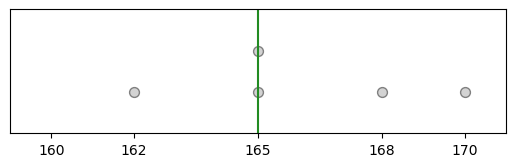

In [29]:
np.random.seed(123)

heights_3 = heights.sample(frac=1, replace=True)
plt_sample(heights_3);
print("median:" ,heights_3.median())

## The Bootstrap

- Across all three resamples, we have the medians:

 $$168, 165, 165$$

- The resample medians of 168, 165, and 165 have a mean of 166, which is pretty close to the original datas median (which was 165).

## The Bootstrap

- We can automate this process, randomly creating new "datasets" from our original data
- This is called resampling **with replacement**

In [30]:
measurements = pd.Series([160, 162, 165, 168, 170])
resample = measurements.sample(frac=1, replace=True)
print("resampled values:", list(resample))
print("resampled median:", resample.median())

resampled values: [165, 168, 162, 162, 160]
resampled median: 162.0


## The Bootstrap

+  choose your statistic of interest (e.g., median heights of female students)
+  use `.sample(frac=1, replace=True)` to resample your data and calculate the statistic for the resample.
+  repeat the previous step a lot of times (say, at least 1000 times)
+  look at the distribution of the statistic from all of the resamples (e.g., look at the histogram of all of the resample medians).
    +  The bootstrap distribution provides an approximation of the distribution of the statistic if you were to draw many samples.
    +  E.g., find the 5th and 95th percentiles of the resampled statistics to get an interval which captures the middle 90% of the resampled statistics to approximate the range of values the statisic would fall 90% of times.

### Mammals

- Next, we will look at skewness and bootstrapping in our mammal data

In [31]:
pantheria = pd.read_csv("pantheria.txt", sep="\t")

print(pantheria.shape)

(5416, 55)


### Mammals

Which is a better representation of the centre of the data: the <span style="color: royalblue;">median</span> or <span style="color: crimson;">mean</span>?

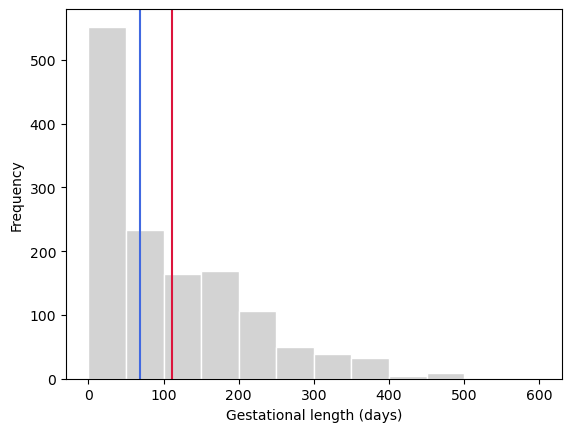

In [32]:
pantheria["9-1_GestationLen_d"].plot.hist(color="lightgrey", edgecolor="white", bins=np.arange(0, 650, 50))
plt.axvline(x=pantheria["9-1_GestationLen_d"].median(), color="royalblue")
plt.axvline(x=pantheria["9-1_GestationLen_d"].mean(), color="crimson")
plt.ylabel("Frequency")
plt.xlabel("Gestational length (days)");

## Bootstrapping our median

- Draw a random sample with replacement of the same size (number of rows) as the original sample.

- This opens the possibility for the new sample to be different from the original sample.

median: 71.48


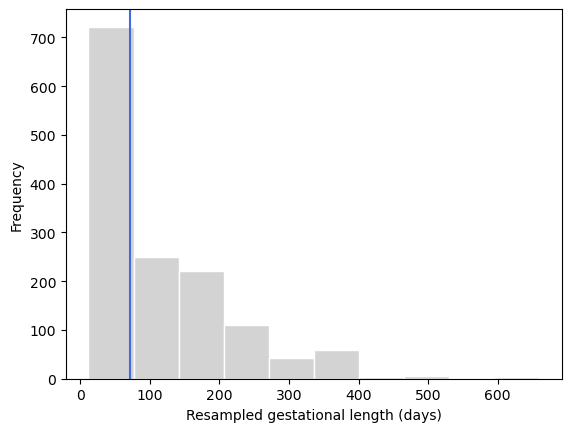

In [33]:
np.random.seed(20260318) # To keep your solution consistent

boot_gest = pantheria["9-1_GestationLen_d"].sample(frac=1, replace=True)

boot_gest.plot.hist(color="lightgrey", edgecolor="white") 
plt.axvline(x=boot_gest.median(), color="royalblue")
plt.ylabel("Frequency")
plt.xlabel("Resampled gestational length (days)");

print("median:", boot_gest.median())

### Resampled median

- We generated one resampled or *bootstrapped* median above.

- By resampling many times we can compute the empirical distribution of the median gestation time.

In [36]:
bootstrap_medians = []  # empty list to collect medians

np.random.seed(717)

for _ in range(1000):
    sim_median = pantheria["9-1_GestationLen_d"].sample(frac=1, replace=True).median()
    bootstrap_medians.append(sim_median)

median estimate: 68.41


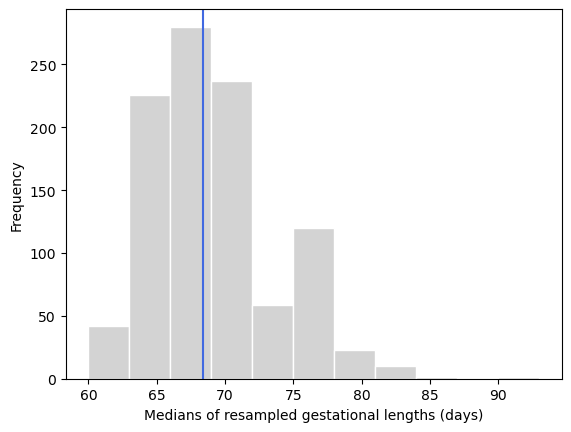

In [37]:
plt.hist(bootstrap_medians, color="lightgrey", edgecolor="white", bins=np.arange(60, 95, 3))
plt.ylabel("Frequency")
plt.xlabel("Medians of resampled gestational lengths (days)");
plt.axvline(x=np.median(bootstrap_medians), color="royalblue");
print("median estimate:",np.median(bootstrap_medians))

### Boostrap confidence intervals

- We can use the bootstrap distribution to construct a range of values such that 95% of the random samples will contain the true median.

- The range of values is called a confidence interval.

- A 95% confidence interval for the median can be constructed finding the 2.5% percentile and the 97.5% percentile.  

- The reason for choosing 2.5% and 97.5% is that 0.05/2 = 0.025, and 1 - 0.025 = 0.975.   

- We can do this using the `percentile` function in `numpy`.

In [38]:
np.percentile(bootstrap_medians, 2.5)

np.float64(62.57)

In [39]:
np.percentile(bootstrap_medians, 97.5)

np.float64(78.63)

### Boostrap confidence intervals


A 95% bootstrap confidence interval for our estimate of the median is 62.99 days to 78.21 days

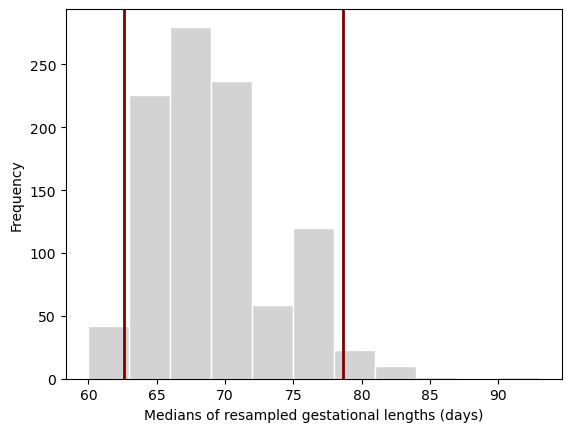

In [40]:
lwr = np.percentile(bootstrap_medians, 2.5)
upr = np.percentile(bootstrap_medians, 97.5)
plt.hist(bootstrap_medians, color="lightgrey", edgecolor="white", bins=np.arange(60, 95, 3))
plt.axvline(x=lwr, color="maroon", linewidth=2)
plt.axvline(x=upr, color="maroon", linewidth=2)
plt.ylabel("Frequency")
plt.xlabel("Medians of resampled gestational lengths (days)");

## What does this mean?

- We wanted to estimate the median gestational length of _all_ mammals
- We only have measurements from _some_ mammals
- **What range of values might the true median fall within?**

## Bootstrap confidence intervals for other statistics

### Do Primates have different body sizes compared to Carnivorans?

- Let's create a dataset (`DataFrame`) with Primate and Carnivoran body mass measurements. 

In [41]:
cols = ["MSW05_Order", "5-1_AdultBodyMass_g"]

condition = (pantheria["MSW05_Order"] == "Primates") | (pantheria["MSW05_Order"] == "Carnivora")

primcarn_df = pantheria.loc[condition, cols].dropna()  # .loc[rows, columns]

primcarn_df.groupby("MSW05_Order").describe()

5-1_AdultBodyMass_g                                               \
                          count          mean            std    min      25%   
MSW05_Order                                                                    
Carnivora                 250.0  47386.453560  153411.127148  78.45  1401.37   
Primates                  265.0   5880.936113   13134.573529  31.23   749.47   

                                              
                  50%        75%         max  
MSW05_Order                                   
Carnivora    3592.265  12948.115  1600000.00  
Primates     3005.990   7077.660   149325.19

### Do Primates have different body sizes compared to Carnivorans?


In [42]:
prim_median = primcarn_df.loc[primcarn_df["MSW05_Order"] == "Primates", "5-1_AdultBodyMass_g"].median()
carn_median = primcarn_df.loc[primcarn_df["MSW05_Order"] == "Carnivora", "5-1_AdultBodyMass_g"].median()
obs_diff = carn_median - prim_median
print("difference between medians:",obs_diff)

difference between medians: 586.2750000000001


Create a function to create one bootstrap sample of the median difference.

In [44]:
def boot_single_median_diff():
    """Generate a bootstrapped difference in adult body mass medians.
    
    The function computes the difference of the medians by subtracting the bootstrapped median
    of primates from the bootstrapped median of carnivoras.
    """
    # sample body mass with replacement
    boot_mass = primcarn_df.sample(frac=1, replace=True)
    # primate rows
    primes = boot_mass["MSW05_Order"] == "Primates"
    # carnivora rows
    carns = boot_mass["MSW05_Order"] == "Carnivora"
    
    # compute difference in medians on bootstrap sample
    boot_mass_med_diff = (
        boot_mass.loc[carns, "5-1_AdultBodyMass_g"].median() 
        - boot_mass.loc[primes, "5-1_AdultBodyMass_g"].median())    # carnivores - primates
    return boot_mass_med_diff

In [51]:
boot_single_median_diff()

835.1850000000004

Now, compute bootstrap distribution for a `for` loop.

In [52]:
bootst_med_diffs = []

for _ in range(5000):
    bootst_med_diffs.append(boot_single_median_diff())

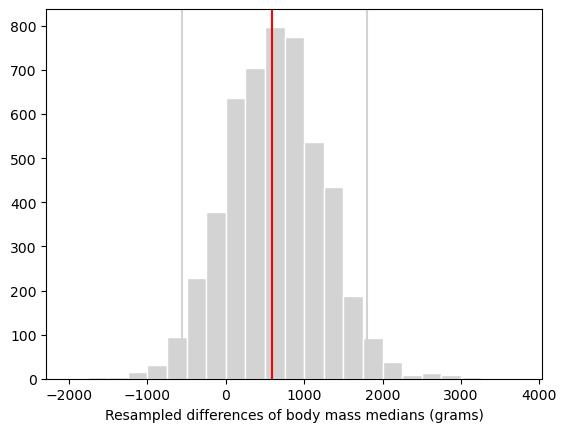

In [54]:
plt.hist(bootst_med_diffs, color="lightgrey", edgecolor="white", bins=np.arange(-2000, 4000, 250))
lower_ci = np.percentile(bootst_med_diffs, 2.5); upper_ci = np.percentile(bootst_med_diffs, 97.5) 
plt.axvline(x=lower_ci, color='lightgrey')
plt.axvline(x=upper_ci, color='lightgrey')
plt.axvline(x=obs_diff, color='red')
#plt.axvline(x=np.median(bootst_med_diffs), color='blue', linestyle='--')

plt.xlabel("Resampled differences of body mass medians (grams)");

## Overview

Hypothesis testing covered how to:
+ test if a percentage (statistic) is different from some hypothesized values.
+ test if two different groups have different means (or median).

Confidence intervals covered how to:
+ get a range of values which estimate a parameter (i.e., mean, median, percentage).
+ get a range of values which estimate the difference in means (or medians) of two different groups.

With linear regression we will cover how to:
+ look at the relationship between two columns in a data frame. (E.g., the relationship between height and mass of mammals).

## Linear Regression

### Basic idea

- Suppose we have two variables and we want to know if they are related
- For example, suppose we want to see how strongly mammalian body mass predicts lifespan
- We can construct a linear model to explore this relationship

### Example 1: A perfect linear relationship 

In [55]:
import pandas as pd
import numpy as np

data = {"indvar" : np.arange(start=0, stop=9, step=1),
       "depvar" : np.arange(start=7, stop=16, step=1)}

df = pd.DataFrame(data)

df

,indvar,depvar
0,0,7
1,1,8
2,2,9
3,3,10
4,4,11
5,5,12
6,6,13
7,7,14
8,8,15


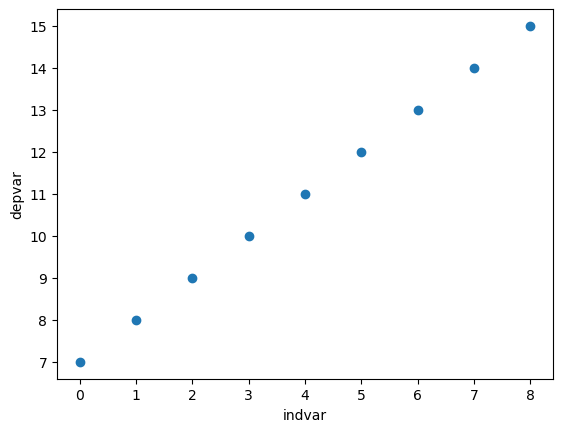

In [56]:
import matplotlib.pyplot as plt

plt.scatter(x=df["indvar"], y=df["depvar"])
plt.xlabel("indvar")
plt.ylabel("depvar");

### Linear regression

- We want to construct a **model** of the relationship bewteen our variables
    - we will call these variables _x_ and _y_
- A simple model we can use is the familiar linear model:
$$ y = mx + b$$
- Our slope (_m_) and y-intercept (_b_) will be **parameters**
   - They describe the relationship between the variables (x and y)

### Linear regression

Essentially we have some data and want to estimate the line. 

<img src="line.png" width="400" style="float:left; margin: 5px 25px;">

We call the estimated line $Y = m X + b $, where:
+ $b$ is the estimated y-intercept
+ $m$ is the estimated slope

### Linear regression

- We want to model the relationship between a(n):
    - _independent_ variable (this is _Y_ in our linear model);
    - a _dependent_ variable (this is _X_ in our linear model)


### Compute the regression line

In [58]:
import statsmodels.formula.api as smf

regmod = smf.ols("depvar ~ indvar", data=df) # setup the model
regmod

### Linear regression

- The code above uses the `ols()` function from `statsmodels.formula.api` 

- The syntax in the function `ols()` function `"depvar ~ indvar"` is a special syntax for describing statistical models.  

- The column name to the **left** of `~` specifies the dependent variable.

- The column name to the **right** of `~` specifies the independent variable(s).

### Linear regression

After the model is setup then the `fit` function can be applied to the model.  This function computes the equation of the regression line.

In [60]:
regmod_fit = regmod.fit() # estimate/fit the model 
regmod_fit

In [61]:
regmod_fit.params # get parameter estimates

Intercept    7.0
indvar       1.0
dtype: float64

### Linear regression

- The estimates of the **y-intercept** and **slope** are labelled `Intercept` (7.0)  and `indvar` (1.0).

- This means the regression equation is: $$\texttt{depvar} = 1 \texttt{indvar} + 7 $$ or $$Y = 1 X + 7$$

### Interpretation of y-intercept

- When the independent variable is 0 the dependent variable is 7
- This is the meaning of the **y-intercept** value of 7



### Interpretation of slope

- For a one-unit change in the independent variable, the dependent variable increases by 1 unit

### Linear regression

- We have constructed a model that captures the perfectly linear relationship between _X_ and _Y_
- In the real world, perfect relationships rarely exist
- Instead, our data is filled with **noise**
    - Measurement error
    - Confounding variables
    - Purely random variation

### Linear regression

- Instead, we fit a model that assumes a linear relationship like we saw before, but where added **error** ($\epsilon$) exists:
  $$ Y = mX + b + \epsilon$$
- We fit the linear model that minimizes the amount of noise implied by the data around our linear line
    - We will explore exactly how this works in more formal detail next week

### Example 2: Linear with noise

- Example 1 was a perfect linear relationship

- What happens when there is noise?

In [62]:
np.random.seed(717) # set the seed so that it's reproducible

data = {"depvar" : np.arange(start=0, stop=8, step=1) + 2 + np.random.uniform(low=0, high=2, size=8),
        "indvar" : np.arange(start=0, stop=8, step=1)}

df = pd.DataFrame(data)

df

,depvar,indvar
0,3.303648,0
1,4.461039,1
2,4.386735,2
3,6.039354,3
4,7.352767,4
5,8.608890,5
6,9.067026,6
7,10.816068,7


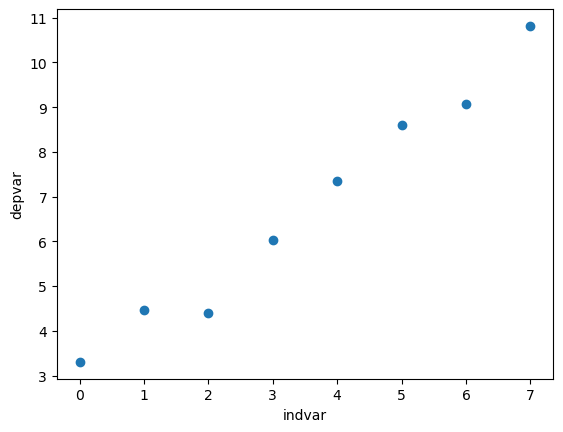

In [63]:
plt.scatter(x=df["indvar"], y=df["depvar"])
plt.xlabel("indvar")
plt.ylabel("depvar");

In [64]:
regmod = smf.ols("depvar ~ indvar", data=df) # setup the model

regmod_fit = regmod.fit() # estimate/fit the model 

regmod_fit.params # get parameter estimates

Intercept    3.021243
indvar       1.066628
dtype: float64

### Linear regression

So, now the relationship isn't perfectly linear, but close.  The equation of this regression line is:

$$Y = 3.021243 X + 1.066628 $$

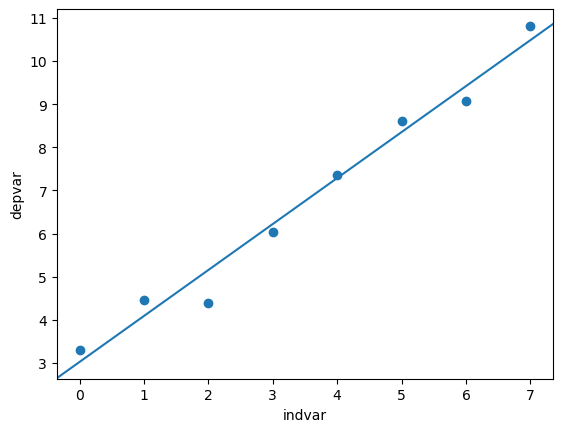

In [65]:
plt.scatter(x=df["indvar"], y=df["depvar"])
plt.axline(xy1=(0, 3.021243), slope=1.066628)
plt.xlabel("indvar")
plt.ylabel("depvar")
plt.show()

### Statistical summary of linear regression

In [66]:
import warnings
warnings.filterwarnings("ignore") # turn off warnings

regsum = regmod_fit.summary()
# warnings.filterwarnings("default") # turn warnings back on
print(regsum)

                            OLS Regression Results                            
Dep. Variable:                 depvar   R-squared:                       0.977
Model:                            OLS   Adj. R-squared:                  0.973
Method:                 Least Squares   F-statistic:                     250.7
Date:                Wed, 18 Mar 2026   Prob (F-statistic):           4.03e-06
Time:                        18:50:38   Log-Likelihood:                -3.5708
No. Observations:                   8   AIC:                             11.14
Df Residuals:                       6   BIC:                             11.30
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.0212      0.282     10.720      0.0

### Linear regression

- A statistical summary of the regression model is given above using the `summary` function in `statsmodels`.

- There are three summary tables, but we will only be interested in the second summary table --- `regsum.tables[1]` (in this course).

### Linear regression

- `coef`: same values as `regmod_fit.params` (parameter estimates)
- `P>|t|`: p-value corresponding to the null hypothesis that the intercept or slope are equal to 0
- `[0.025   0.975]`: plausible range of values for the y-intercept and slope (formally known as a 95% confidence interval)

In [67]:
regsum.tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,3.0212,0.282,10.720,0.000,2.332,3.711
indvar,1.0666,0.067,15.833,0.000,0.902,1.231


### Linear regression

If you are curious:
- `std err`: the standard deviation of the intercept and slope (we won't discuss in this course)
- `t`: value of the t-statistic (we won't discuss in this course)

### Fitted/predicted values

- We may wish to know what values the model predicts for the dependent variable given a value for the independent variable
- We can find these **fitted** or **predicted** values by just plugging our X values into the linear equation with our parameters
 
$$Y = 1.0666X + 3.0212 $$

### Fitted/predicted values and residuals

The **fitted value** for the first row of `df` is:

In [68]:
regmod_fit.params[0] + regmod_fit.params[1] * df.loc[0, "indvar"]

np.float64(3.0212428738381965)

### Fitted/predicted values


To extract the fitted values from a regression model access the `fittedvalues` attribute of the fitted `statsmodels` object.

In [69]:
regmod_fit.fittedvalues

0     3.021243
1     4.087871
2     5.154499
3     6.221127
4     7.287755
5     8.354383
6     9.421011
7    10.487639
dtype: float64

### Residuals

- The **residual** is how far above or below the line a point is 

- So, it is the dependent variable minus the fitted value

In [70]:
df.loc[0, "depvar"] - regmod_fit.fittedvalues[0]

np.float64(0.28240518195995845)

### Residuals

- Residuals reflect our model of the error term $\epsilon$
- We pick the model that has the lowest sum of squared residuals
- We will learn more about residuals next week

## Accuracy of linear regression

- We may want to know how well our linear model explains our data

- One popular measure of this is called **R-squared**

    - The _proportion of variation in the relationship between X and Y explained by our model_

In [71]:
regmod_fit.rsquared

np.float64(0.9766246713446016)

### Example 4: Regression with two or more independent variables

It's possible to include more than one independent variable in a regression model.  

In [72]:
np.random.seed(11) #set the seed so that it's reproducible

data = {"depvar" : np.arange(start=0, stop=8, step=1) + 2,
        "indvar1" : np.arange(start=0, stop=8, step=1) + np.random.uniform(low=0, high=2, size=8),
        "indvar2" : np.arange(start=0, stop=8, step=1) + np.random.normal(loc=0, scale=1, size=8)}

df = pd.DataFrame(data)

df

,depvar,indvar1,indvar2
0,2,0.360539,-0.536629
1,3,1.038950,1.315403
2,4,2.926437,2.421051
3,5,4.449868,1.934397
4,6,4.840407,3.113760
5,7,5.970854,4.524267
6,8,6.025562,6.689682
7,9,7.974743,7.561192


To include more than one independent variable in a regression model add it to the right side of syntax for describing statistical models.

`"depvar ~ indvar1 + indvar2"`

In [73]:
regmod = smf.ols("depvar ~ indvar1 + indvar2", data=df) # setup the model

Now `fit` `regmod`.

In [74]:
regmod_fit = regmod.fit() # estimate/fit the model 

Extract the regression parameter estimates using `params`.

In [75]:
regmod_fit.params # get parameter estimates

Intercept    1.892482
indvar1      0.549341
indvar2      0.385197
dtype: float64

### Multiple regression

The estimated linear (multiple) linear regression model is:

$$\texttt{depvar} = 1.892482 + 0.549341 \times \texttt{indvar1} + 0.385197 \times \texttt{indvar2}$$

- The y-intercept value (1.892482) is the value of the dependent variable when `indvar1` and `indvar2` are both 0.

-  If `indvar1` changes by one-unit, `depvar` changes (on average) by 0.549341.

-  If `indvar2` changes by one-unit, `depvar` changes (on average) by 0.385197. 

### Statistical summary of a multiple regression model

- Like for the single regression model, we can explore the summary of our model

In [76]:
multregsummary = regmod_fit.summary()

multregsummary.tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,1.8925,0.201,9.432,0.000,1.377,2.408
indvar1,0.5493,0.102,5.411,0.003,0.288,0.810
indvar2,0.3852,0.097,3.984,0.010,0.137,0.634


### Accuracy of multiple regression model

- And also similarly, we can examine R-squared:

In [77]:
regmod_fit.rsquared

np.float64(0.9914100322269062)

## A regression model of gestation length on longevity 

### Data

- Pantheria data contains data on lifespan (longevity) and gestation length.

In [ ]:
pantheria = pd.read_csv("pantheria.txt", sep="\t")
pantheria.head()

In [ ]:
cols = ["5-1_AdultBodyMass_g", "17-1_MaxLongevity_m", "9-1_GestationLen_d", "MSW05_Binomial"]

panthdat_trans = pantheria[cols]

colnames = {cols[0] : "bodymass",
            cols[1] : "longevity",
            cols[2] : "gestation",
            cols[3] : "name"}

panthdat_trans = panthdat_trans.copy()

panthdat_trans.rename(columns=colnames, inplace=True)

panthdat_trans.head()

### Longevity vs gestation length


In [ ]:
plt.scatter(y=panthdat_trans["gestation"], x=panthdat_trans["longevity"],
            alpha=.3) # helps display overlapping data values 
plt.xlabel("Longevity (months)")
plt.ylabel("Gestation (days)");

## A regression model of length of longevity on gestation

### Fit the regression model

In [ ]:
import statsmodels.formula.api as smf

reg_longgest = smf.ols("gestation ~ longevity", data=panthdat_trans) # setup the model

reg_longgest_fit = reg_longgest.fit() # estimate/fit the model 

## Statistical summary of the regression model

In [ ]:
reg_longgest_summ = reg_longgest_fit.summary()

reg_longgest_summ.tables[1]

- The regression equation is: $\texttt{gestation} = 38.6062 + 0.431\times \texttt{longevity}$
- The **slope** indicates that for a 1 month **increase** in longevity, we expect the gestational period to increase by 0.43 days.
- The **y-intercept** indicates that when longevity is 0 months, gestational period is 38.6 days.

### Interpreting regression models

- Are there any species with 0 days longevitiy?

### Interpreting regression models

- Are there any species with 0 days longevitiy?
- The **y-intercept** in regression models often doesn't have a sensible interpretation, but is mathematically important for regression to work

### Accuracy of regression models

In [ ]:
reg_longgest_fit.rsquared

### Accuracy of regression model

- This $R^2$ is pretty far from 1
    - Our model explains only ~48% of the variation between longevity and gestation time 
- We can probably do better, but we will save model improvements for next week

## Linear regression models

The regression model appears to provide an okay to moderate fit the data. The scatter plot indicated that there is a lot of variation in gestational length based on the different longevities

- As longevity increases, we expect gestational length to increase too